In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit import DataStructs
import numpy as np
import pandas as pd

smiles = "CCO"  # ethanol
mol = Chem.MolFromSmiles(smiles)

print("Molecule loaded:", mol is not None)
print("Number of atoms:", mol.GetNumAtoms())

Molecule loaded: True
Number of atoms: 3


In [2]:
# Morgan fingerprint / circular fingerprint
morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

morgan_arr = np.zeros((2048,), dtype=int)
DataStructs.ConvertToNumpyArray(morgan_fp, morgan_arr)

print("Morgan fingerprint length:", len(morgan_arr))
print("Number of active bits:", morgan_arr.sum())
print("First 50 bits:", morgan_arr[:50])

Morgan fingerprint length: 2048
Number of active bits: 6
First 50 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


[16:07:48] DEPRECATION WARNING: please use MorganGenerator


In [3]:
example_compounds = pd.DataFrame({
    "name": ["ethanol", "aspirin", "caffeine", "ibuprofen"],
    "smiles": [
        "CCO",
        "CC(=O)OC1=CC=CC=C1C(=O)O",
        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
        "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
    ]
})

example_compounds

,name,smiles
0,ethanol,CCO
1,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O
2,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C
3,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O


In [4]:
def smiles_to_morgan_array(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

fingerprints = []

for smiles in example_compounds["smiles"]:
    arr = smiles_to_morgan_array(smiles)
    fingerprints.append(arr)

fingerprint_df = pd.DataFrame(fingerprints)
fingerprint_df.insert(0, "name", example_compounds["name"])
fingerprint_df.insert(1, "smiles", example_compounds["smiles"])

fingerprint_df.head()

[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator


,name,smiles,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,ethanol,CCO,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
fingerprint_df.to_csv("example_morgan_fingerprints.csv", index=False)
print("Saved example_morgan_fingerprints.csv")

Saved example_morgan_fingerprints.csv


In [1]:
# json

In [2]:
from pathlib import Path
import json

file_path = Path.home() / "predicting-predictability" / "data" / "drug_master.json"

print(file_path)
print("File exists:", file_path.exists())
print("File size MB:", file_path.stat().st_size / 1_000_000)

with open(file_path, "r") as f:
    drug_master = json.load(f)

print(type(drug_master))
print(len(drug_master))

/Users/mell/predicting-predictability/data/drug_master.json
File exists: True
File size MB: 2.959962
<class 'dict'>
6801


In [3]:
if isinstance(drug_master, dict):
    first_key = list(drug_master.keys())[0]
    print("First key:", first_key)
    print(drug_master[first_key])
else:
    print(drug_master[0])

First key: be-2254
{'name': 'be-2254', 'pubchem_cid': '86308637', 'inchi_key': 'PZZOEXPDTYIBPI-MRXNPFEDSA-N', 'smiles': 'Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|', 'broad_id': 'BRD-A24429032-003-03-2', 'moa': 'adrenergic receptor antagonist', 'target': 'ADRA1A', 'clinical_phase': 'Phase 2', 'disease_area': '', 'indication': '', 'fda_approved': False}


In [4]:
import pandas as pd

drugs_df = pd.DataFrame.from_dict(drug_master, orient="index")
drugs_df.insert(0, "record_id", drugs_df.index)

print(drugs_df.shape)
drugs_df.head()

(6801, 12)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
be-2254,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
tasimelteon,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
esaxerenone,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
ixazomib-citrate,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
alendronate,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [5]:
smiles_col = "smiles"

drugs_with_smiles = drugs_df[
    drugs_df[smiles_col].notna() &
    (drugs_df[smiles_col].astype(str).str.strip() != "")
].copy()

print("Compounds with SMILES:", drugs_with_smiles.shape[0])
drugs_with_smiles.head()

Compounds with SMILES: 6776


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
be-2254,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
tasimelteon,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
esaxerenone,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
ixazomib-citrate,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
alendronate,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [6]:
# real morgan

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pandas as pd

def smiles_to_morgan_array(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

fingerprints = []
valid_rows = []
invalid_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    arr = smiles_to_morgan_array(smiles)
    
    if arr is None:
        invalid_smiles.append((idx, smiles))
    else:
        fingerprints.append(arr)
        valid_rows.append(row)

valid_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)

morgan_df = pd.DataFrame(
    fingerprints,
    columns=[f"morgan_{i}" for i in range(2048)]
)

perturbseqr_morgan_df = pd.concat(
    [valid_drugs_df.reset_index(drop=True), morgan_df],
    axis=1
)

print("Valid compounds:", perturbseqr_morgan_df.shape[0])
print("Invalid SMILES:", len(invalid_smiles))
print("Final table shape:", perturbseqr_morgan_df.shape)

perturbseqr_morgan_df.head()

[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerat

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 2060)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,0,0,0,0,0,0,0,0,0,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,0,0,0,0,0,0,0,0,0,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,0,0,0,0,0,0,0,0,0,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,0,0,0,0,0,0,0,0,0,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from pathlib import Path

output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_morgan_fingerprints.csv"

perturbseqr_morgan_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_morgan_fingerprints.csv


In [9]:
# Generate MACCS keys for Perturb-Seqr compounds

In [10]:
from rdkit.Chem import MACCSkeys

def smiles_to_maccs_array(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((167,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

maccs_fingerprints = []
valid_rows = []
invalid_maccs_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    arr = smiles_to_maccs_array(smiles)
    
    if arr is None:
        invalid_maccs_smiles.append((idx, smiles))
    else:
        maccs_fingerprints.append(arr)
        valid_rows.append(row)

valid_maccs_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)

maccs_df = pd.DataFrame(
    maccs_fingerprints,
    columns=[f"maccs_{i}" for i in range(167)]
)

perturbseqr_maccs_df = pd.concat(
    [valid_maccs_drugs_df.reset_index(drop=True), maccs_df],
    axis=1
)

print("Valid compounds:", perturbseqr_maccs_df.shape[0])
print("Invalid SMILES:", len(invalid_maccs_smiles))
print("Final table shape:", perturbseqr_maccs_df.shape)

perturbseqr_maccs_df.head()

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 179)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,1,1,1,0,1,1,1,1,1,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,1,1,1,1,1,1,1,1,1,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,1,1,1,1,1,1,1,1,1,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,1,1,1,1,1,1,1,1,1,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,1,1,1,0,1,0,0,1,0,0


In [11]:
output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_maccs_keys.csv"

perturbseqr_maccs_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_maccs_keys.csv


In [12]:
# Generate molecular descriptors for Perturb-Seqr compounds

In [13]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    return {
        "molecular_weight": Descriptors.MolWt(mol),
        "logP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "h_bond_donors": Lipinski.NumHDonors(mol),
        "h_bond_acceptors": Lipinski.NumHAcceptors(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
        "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "heavy_atoms": Descriptors.HeavyAtomCount(mol),
        "formal_charge": Chem.GetFormalCharge(mol)
    }

descriptor_rows = []
valid_rows = []
invalid_descriptor_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    desc = smiles_to_descriptors(smiles)
    
    if desc is None:
        invalid_descriptor_smiles.append((idx, smiles))
    else:
        descriptor_rows.append(desc)
        valid_rows.append(row)

valid_descriptor_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)
descriptor_df = pd.DataFrame(descriptor_rows)

perturbseqr_descriptors_df = pd.concat(
    [valid_descriptor_drugs_df.reset_index(drop=True), descriptor_df],
    axis=1
)

print("Valid compounds:", perturbseqr_descriptors_df.shape[0])
print("Invalid SMILES:", len(invalid_descriptor_smiles))
print("Final table shape:", perturbseqr_descriptors_df.shape)

perturbseqr_descriptors_df.head()

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 21)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,fda_approved,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,False,295.382,2.96960,49.33,2,3,5,2,22,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,True,245.322,2.25120,38.33,1,2,4,1,18,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,False,466.481,4.13042,88.40,2,4,6,3,32,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,True,517.127,1.54310,168.33,4,7,10,1,34,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,True,249.096,-1.27320,161.31,6,4,5,0,14,0


In [14]:
output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_molecular_descriptors.csv"

perturbseqr_descriptors_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_molecular_descriptors.csv


In [1]:
# Gather CACTVS/PubChem fingerprints

In [2]:
import sys
print(sys.executable)

import pubchempy as pcp
from tqdm import tqdm
print("PubChemPy works")

/opt/miniconda3/envs/my-rdkit-env/bin/python
PubChemPy works


In [3]:
# Check what dataframes already exist in the notebook

In [5]:
from pathlib import Path
import pandas as pd

data_path = Path.home() / "predicting-predictability" / "data" / "drug_master.json"

compounds_df = pd.read_json(data_path).T.reset_index(drop=True)

print(compounds_df.shape)
compounds_df.head()

(6801, 11)


,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
0,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
1,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
2,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
3,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
4,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [6]:
# Identify the PubChem CID column

In [7]:
CID_COL = "pubchem_cid"

In [8]:
# Preview the CID values

In [9]:
compounds_df[[CID_COL]].head()

,pubchem_cid
0,86308637
1,10220503
2,25052023
3,69040311
4,44400013


In [10]:
# Test CACTVS/PubChem fingerprint retrieval for one compound

In [11]:
import pubchempy as pcp

test_cid = compounds_df[CID_COL].dropna().iloc[0]

compound = pcp.Compound.from_cid(int(test_cid))
test_fp = compound.cactvs_fingerprint

print("CID:", test_cid)
print("Fingerprint length:", len(test_fp))
print("First 50 bits:", test_fp[:50])

CID: 86308637
Fingerprint length: 881
First 50 bits: 11100000011110100011000000000000000000000000000000


In [13]:
# Define a function to retrieve one CACTVS/PubChem fingerprint from PubChem

def get_cactvs_fingerprint(cid):
    """
    Retrieve the PubChem CACTVS fingerprint for one compound using its PubChem CID.
    Return None if the CID is missing or if PubChem lookup fails.
    """
    if pd.isna(cid):
        return None
    
    try:
        compound = pcp.Compound.from_cid(int(cid))
        return compound.cactvs_fingerprint
    except Exception:
        return None

In [14]:
# Retrieve CACTVS/PubChem fingerprints for all Perturb-Seqr compounds

In [15]:
import time
from tqdm import tqdm

fingerprints = []

for cid in tqdm(compounds_df[CID_COL], desc="Fetching CACTVS/PubChem fingerprints"):
    fp = get_cactvs_fingerprint(cid)
    fingerprints.append(fp)
    time.sleep(0.1)

compounds_df["cactvs_pubchem_fp"] = fingerprints

compounds_df[["name", CID_COL, "cactvs_pubchem_fp"]].head()

Fetching CACTVS/PubChem fingerprints: 100%|████████████████████████████████████████| 6801/6801 [44:02<00:00,  2.57it/s]


,name,pubchem_cid,cactvs_pubchem_fp
0,be-2254,86308637,1110000001111010001100000000000000000000000000...
1,tasimelteon,10220503,1110000001110010001100000000000000000000000000...
2,esaxerenone,25052023,1110000001111011001110011000000001000000000000...
3,ixazomib-citrate,69040311,1110001001111011001111000000000000000110000000...
4,alendronate,44400013,1100000001100010001110000000001100000000000000...


In [16]:
# Check how many CACTVS/PubChem fingerprints were successfully retrieved

In [17]:
valid = compounds_df["cactvs_pubchem_fp"].notna()

print("Total compounds:", len(compounds_df))
print("Fingerprints retrieved:", valid.sum())
print("Missing fingerprints:", (~valid).sum())


Total compounds: 6801
Fingerprints retrieved: 6409
Missing fingerprints: 392


In [18]:
# Check fingerprint lengths

In [19]:
compounds_df["cactvs_pubchem_fp"].dropna().str.len().value_counts().head()

cactvs_pubchem_fp
881    6409
Name: count, dtype: int64

In [20]:
# Convert each 881-bit CACTVS/PubChem fingerprint string into separate binary feature columns

In [21]:
fp_strings = compounds_df.loc[valid, "cactvs_pubchem_fp"]

cactvs_bits_df = fp_strings.apply(lambda x: pd.Series(list(x))).astype(int)

cactvs_bits_df.columns = [f"cactvs_{i}" for i in range(cactvs_bits_df.shape[1])]

print(cactvs_bits_df.shape)
cactvs_bits_df.head()

(6409, 881)


,cactvs_0,cactvs_1,cactvs_2,cactvs_3,cactvs_4,cactvs_5,cactvs_6,cactvs_7,cactvs_8,cactvs_9,...,cactvs_871,cactvs_872,cactvs_873,cactvs_874,cactvs_875,cactvs_876,cactvs_877,cactvs_878,cactvs_879,cactvs_880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Combine compound metadata with CACTVS/PubChem fingerprint columns

In [23]:
cactvs_pubchem_df = pd.concat(
    [
        compounds_df.loc[valid].reset_index(drop=True),
        cactvs_bits_df.reset_index(drop=True)
    ],
    axis=1
)

print(cactvs_pubchem_df.shape)
cactvs_pubchem_df.head()

(6409, 893)


,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,...,cactvs_871,cactvs_872,cactvs_873,cactvs_874,cactvs_875,cactvs_876,cactvs_877,cactvs_878,cactvs_879,cactvs_880
0,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,...,0,0,0,0,0,0,0,0,0,0
1,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,...,0,0,0,0,0,0,0,0,0,0
2,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,...,0,0,0,0,0,0,0,0,0,0
3,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,...,0,0,0,0,0,0,0,0,0,0
4,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Save the CACTVS/PubChem fingerprint feature table

In [25]:
from pathlib import Path

output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_cactvs_pubchem_fingerprints.csv"

cactvs_pubchem_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_cactvs_pubchem_fingerprints.csv


In [26]:
# Compare molecular representation table sizes

In [27]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"

files = {
    "Morgan fingerprints": data_dir / "perturbseqr_morgan_fingerprints.csv",
    "MACCS keys": data_dir / "perturbseqr_maccs_keys.csv",
    "Molecular descriptors": data_dir / "perturbseqr_molecular_descriptors.csv",
    "CACTVS/PubChem fingerprints": data_dir / "perturbseqr_cactvs_pubchem_fingerprints.csv"
}

summary_rows = []

for rep_name, file_path in files.items():
    temp_df = pd.read_csv(file_path)
    summary_rows.append({
        "representation": rep_name,
        "num_compounds": temp_df.shape[0],
        "num_columns": temp_df.shape[1],
        "file_name": file_path.name
    })

representation_summary_df = pd.DataFrame(summary_rows)

representation_summary_df

,representation,num_compounds,num_columns,file_name
0,Morgan fingerprints,6754,2060,perturbseqr_morgan_fingerprints.csv
1,MACCS keys,6754,179,perturbseqr_maccs_keys.csv
2,Molecular descriptors,6754,21,perturbseqr_molecular_descriptors.csv
3,CACTVS/PubChem fingerprints,6409,893,perturbseqr_cactvs_pubchem_fingerprints.csv


In [28]:
# Save updated representation comparison summary

In [29]:
output_path = data_dir / "representation_comparison_summary.csv"

representation_summary_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/representation_comparison_summary.csv


In [30]:
# Examine descriptor distributions

In [31]:
# Load molecular descriptor table

In [32]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"
figures_dir = Path.home() / "predicting-predictability" / "figures"

figures_dir.mkdir(exist_ok=True)

descriptors_path = data_dir / "perturbseqr_molecular_descriptors.csv"
descriptors_df = pd.read_csv(descriptors_path)

print(descriptors_df.shape)
descriptors_df.head()

(6754, 21)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,fda_approved,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
0,be-2254,be-2254,86308637.0,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,NaN,...,False,295.382,2.96960,49.33,2,3,5,2,22,0
1,tasimelteon,tasimelteon,10220503.0,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,True,245.322,2.25120,38.33,1,2,4,1,18,0
2,esaxerenone,esaxerenone,25052023.0,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,NaN,Preclinical,NaN,...,False,466.481,4.13042,88.40,2,4,6,3,32,0
3,ixazomib-citrate,ixazomib-citrate,69040311.0,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,NaN,Launched,hematologic malignancy,...,True,517.127,1.54310,168.33,4,7,10,1,34,0
4,alendronate,alendronate,44400013.0,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,True,249.096,-1.27320,161.31,6,4,5,0,14,0


In [33]:
# Select descriptor columns to summarize and plot

In [36]:
descriptor_cols = [
    "molecular_weight",
    "logP",
    "TPSA",
    "h_bond_donors",
    "h_bond_acceptors",
    "rotatable_bonds",
    "aromatic_rings",
    "heavy_atoms",
    "formal_charge"
]

descriptors_df[descriptor_cols].describe()

,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
count,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000
mean,382.475308,2.778816,88.255996,2.117264,4.962541,5.485638,1.977791,26.666420,0.027835
std,202.397102,2.533570,80.676619,2.854669,3.686306,5.633470,1.355437,14.128231,0.198755
min,47.057000,-35.768400,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-2.000000
25%,271.149750,1.515025,49.825000,1.000000,3.000000,3.000000,1.000000,19.000000,0.000000
50%,358.452500,3.021240,75.615000,2.000000,4.000000,5.000000,2.000000,25.000000,0.000000
75%,449.618500,4.274700,104.025000,3.000000,6.000000,7.000000,3.000000,32.000000,0.000000
max,4186.637000,17.853900,1749.750000,58.000000,75.000000,134.000000,10.000000,295.000000,5.000000


In [37]:
# Save descriptor summary statistics

In [38]:
descriptor_summary = descriptors_df[descriptor_cols].describe()

summary_path = data_dir / "descriptor_summary_statistics.csv"
descriptor_summary.to_csv(summary_path)

print("Saved to:", summary_path)

Saved to: /Users/mell/predicting-predictability/data/descriptor_summary_statistics.csv


In [39]:
# Plot descriptor distributions

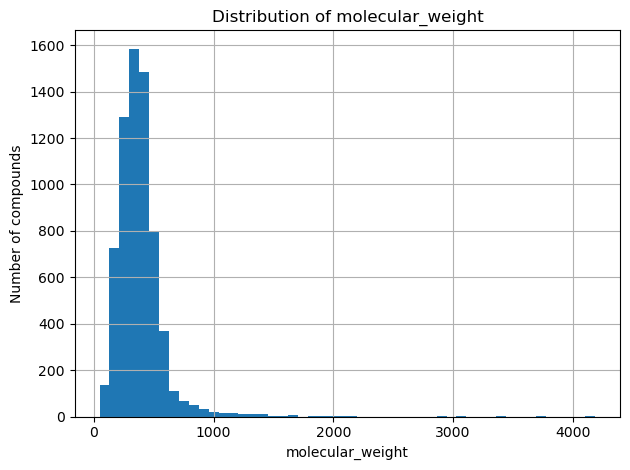

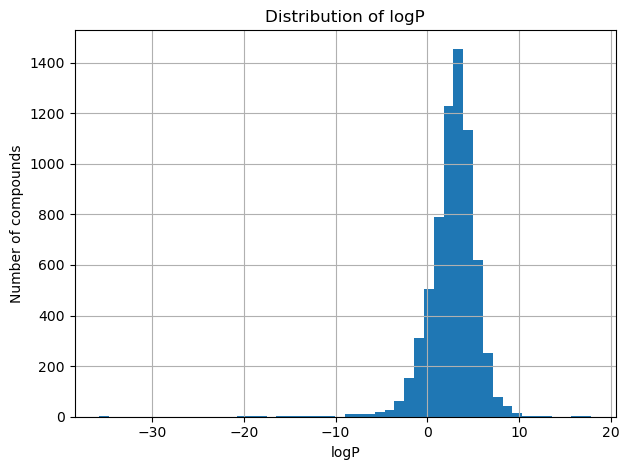

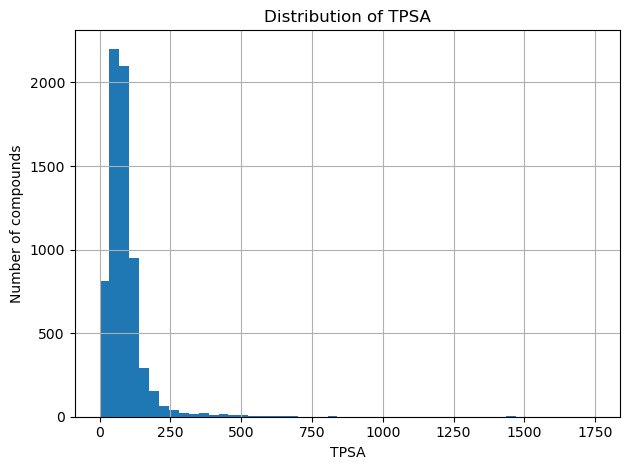

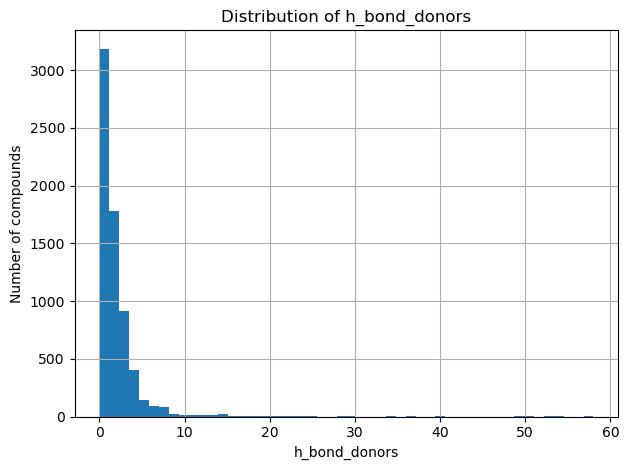

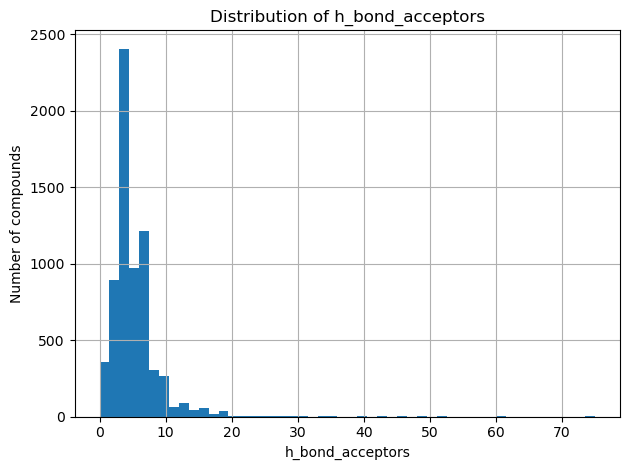

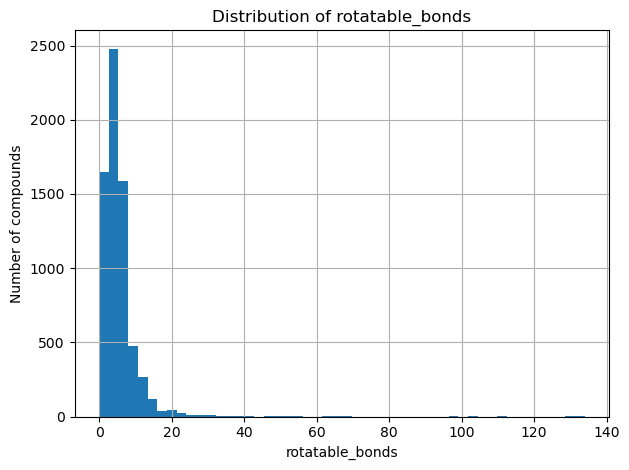

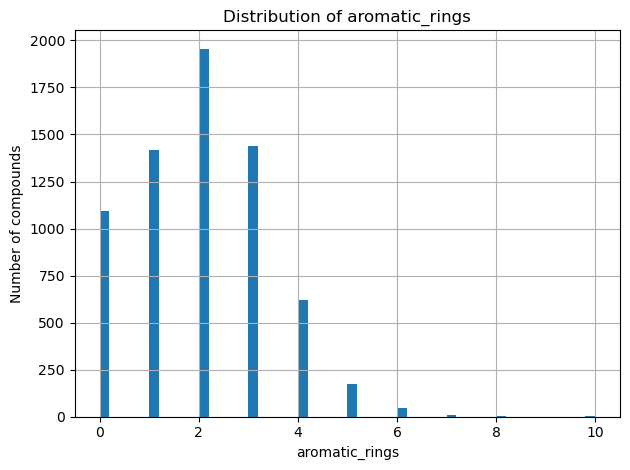

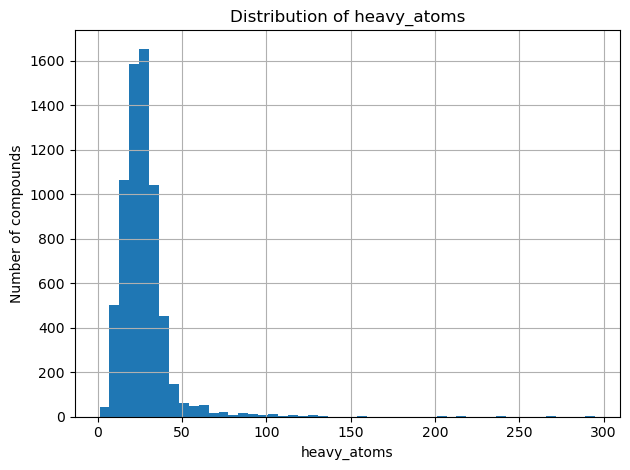

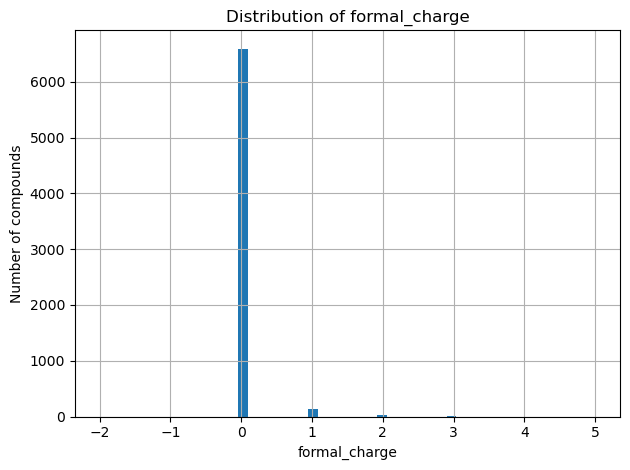

Saved descriptor distribution plots to: /Users/mell/predicting-predictability/figures


In [40]:
import matplotlib.pyplot as plt

for col in descriptor_cols:
    plt.figure()
    descriptors_df[col].dropna().hist(bins=50)
    plt.xlabel(col)
    plt.ylabel("Number of compounds")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    
    output_path = figures_dir / f"distribution_{col}.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

print("Saved descriptor distribution plots to:", figures_dir)